In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

In [2]:
liver_disorders = fetch_ucirepo(id = 60)

In [3]:
# Data as pandas dataframe

X = liver_disorders.data.features
y = liver_disorders.data.targets

In [4]:
# Standardize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
#Define range of regularization parameter values

lambdas = np.logspace(-2,3,100)

In [8]:
# Fit Lasso and Ridge models for different alpha values:

coefs_lasso = []
for alpha in lambdas:
    lasso = Lasso(alpha = alpha, fit_intercept = False)
    lasso.fit(X_scaled, y)
    coefs_lasso.append(lasso.coef_)

In [9]:
# Flatten the 3D array
n_features = X.shape[1]
coefs_lasso_flat = np.array(coefs_lasso).reshape(-1,n_features)

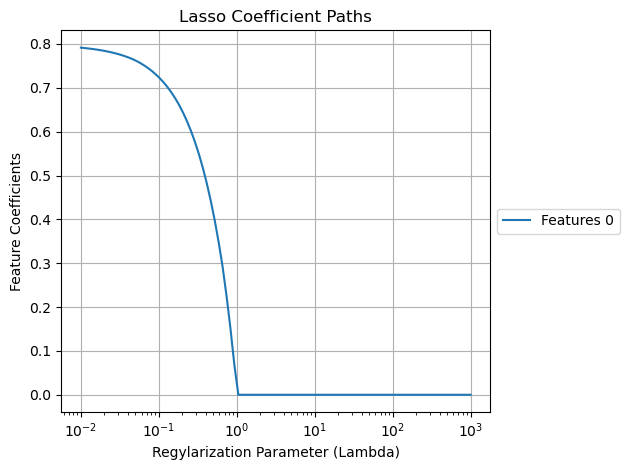

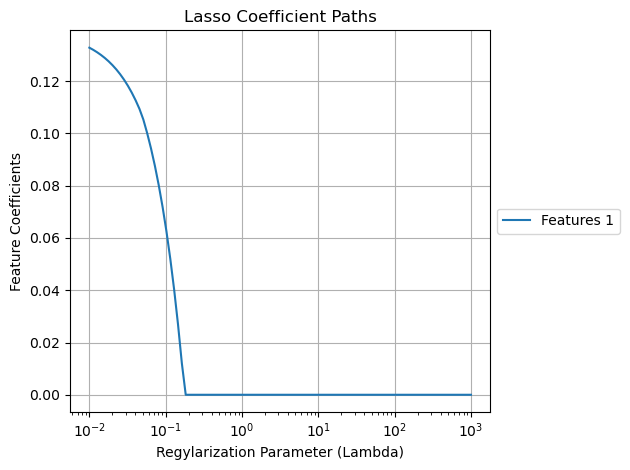

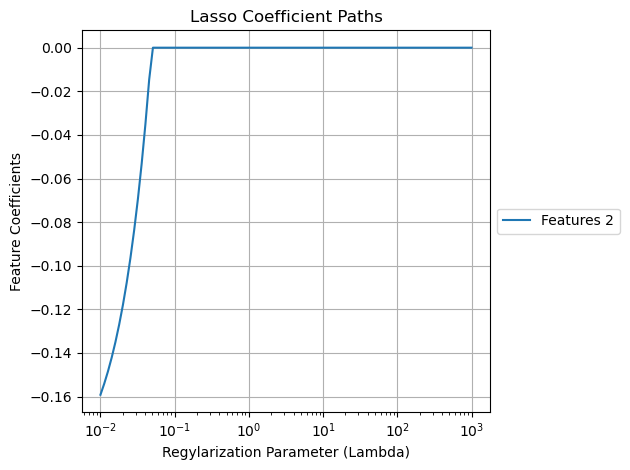

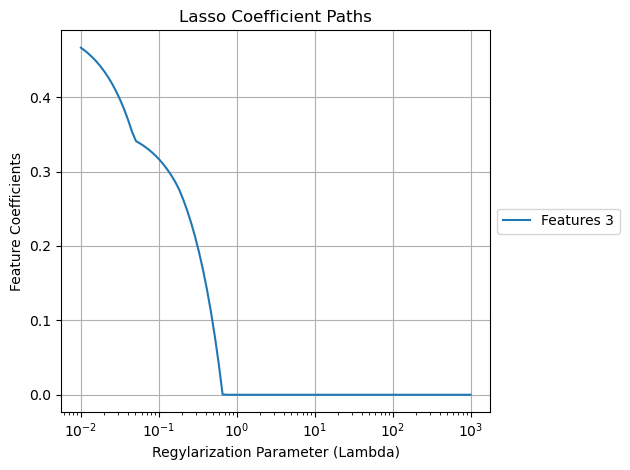

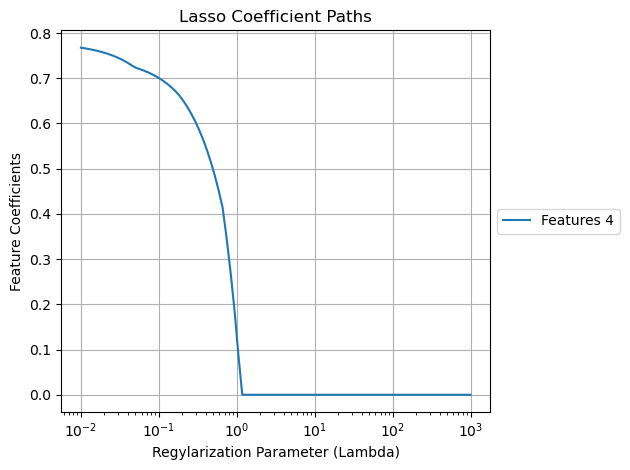

In [11]:
# Plot coefficient paths for Lasso

for i in range(n_features):
    plt.plot(lambdas, coefs_lasso_flat[:,i], label = 'Features {}'.format(i))
    plt.xscale('log')
    plt.xlabel('Regylarization Parameter (Lambda)')
    plt.ylabel('Feature Coefficients')
    plt.title('Lasso Coefficient Paths')
    plt.legend(loc = 'center left', bbox_to_anchor = (1,0.5))
    plt.grid(True)
    plt.tight_layout()
    plt.show()